In [67]:
import pandas as pd
import seaborn as sns
from sqlalchemy import engine
from pandasql import sqldf

pysqldf = lambda q: sqldf(q, globals())

In [68]:
df = pd.read_csv("datos_google_ads.csv")

In [69]:
df.shape

(100, 9)

In [70]:
df.describe()

,Avg. monthly searches,Competition (indexed value),Top of page bid (low range),Top of page bid (high range)
count,100.000000,100.000000,99.000000,100.000000
mean,6390.300000,51.720000,1.036768,3.923800
std,10335.962467,26.603364,0.699648,2.689875
min,50.000000,7.000000,0.110000,0.590000
25%,320.000000,30.500000,0.430000,1.450000
50%,1300.000000,53.000000,0.900000,3.255000
75%,6075.000000,71.250000,1.460000,6.395000
max,40500.000000,97.000000,2.490000,9.130000


In [71]:
df['Keyword'].duplicated().sum()

np.int64(0)

In [72]:
df = df.dropna(subset=['Competition (indexed value)'])

In [73]:
df = df.dropna(subset=['Top of page bid (low range)'])

In [74]:
df

,Keyword,Currency,Avg. monthly searches,Three month change,YoY change,Competition,Competition (indexed value),Top of page bid (low range),Top of page bid (high range)
0,servicios financieros,USD,320,-20%,10%,Low,19,0.17,0.59
1,servicios financieros para empresas,USD,22000,-10%,25%,Medium,56,0.96,4.24
2,servicios financieros en colombia,USD,50,10%,80%,Low,19,0.32,0.95
4,servicios financieros ejemplos,USD,1900,-10%,-15%,Low,11,0.28,0.99
5,servicios financieros importancia,USD,1300,-20%,40%,High,37,1.47,3.73
...,...,...,...,...,...,...,...,...,...
95,productos financieros ventajas,USD,210,15%,40%,Low,34,0.38,1.48
96,productos financieros para negocios,USD,1900,-20%,40%,Medium,41,0.94,3.13
97,productos financieros para emprendedores,USD,1300,20%,10%,High,74,1.37,4.13
98,productos financieros servicios y productos,USD,18100,10%,-15%,Medium,81,1.63,7.80


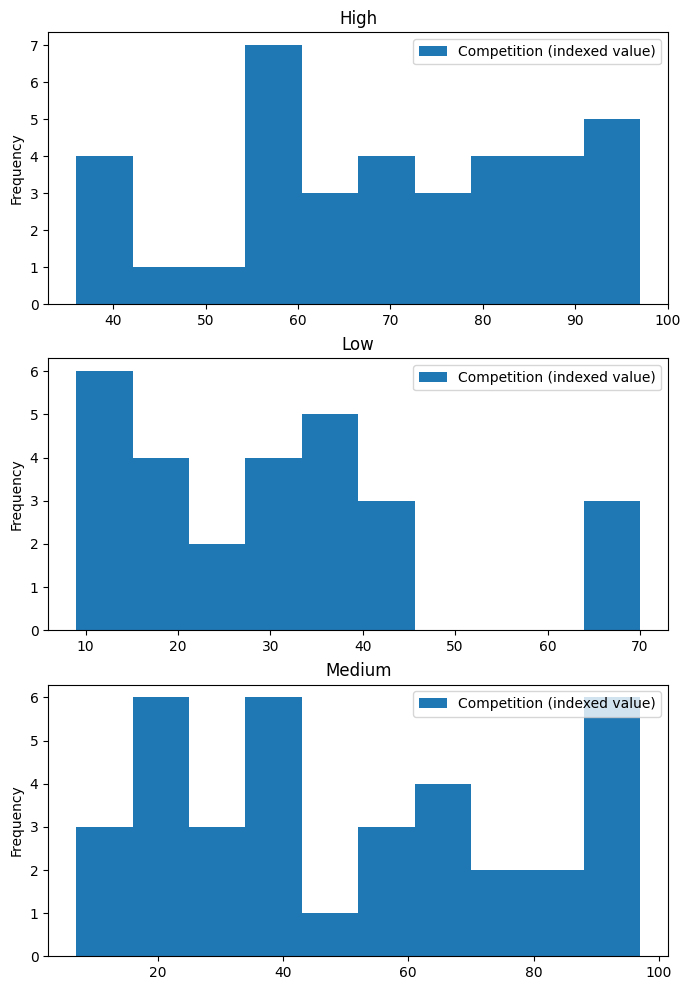

In [75]:
ax = df.plot.hist(column=["Competition (indexed value)"], by='Competition', bins=10, figsize=(8,12))

<Axes: xlabel='Competition', ylabel='Avg. monthly searches'>

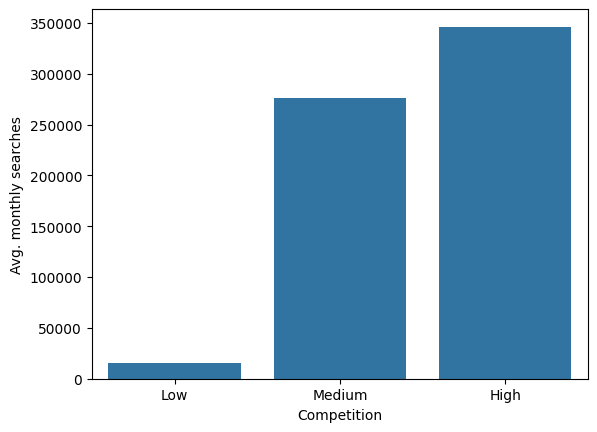

In [76]:
sns.barplot(data=df, x="Competition", y="Avg. monthly searches", errorbar=None, estimator=sum)

In [77]:
df = df.rename(columns={"Avg. monthly searches": "avg_monthly_searches", "Three month change": "three_month_change", "YoY change":"yoy_change", "Competition (indexed value)":"competition_indexed_value", "Top of page bid (low range)":"top_of_page_bid_low", "Top of page bid (high range)":"top_of_page_bid_high"})

In [78]:
df

,Keyword,Currency,avg_monthly_searches,three_month_change,yoy_change,Competition,competition_indexed_value,top_of_page_bid_low,top_of_page_bid_high
0,servicios financieros,USD,320,-20%,10%,Low,19,0.17,0.59
1,servicios financieros para empresas,USD,22000,-10%,25%,Medium,56,0.96,4.24
2,servicios financieros en colombia,USD,50,10%,80%,Low,19,0.32,0.95
4,servicios financieros ejemplos,USD,1900,-10%,-15%,Low,11,0.28,0.99
5,servicios financieros importancia,USD,1300,-20%,40%,High,37,1.47,3.73
...,...,...,...,...,...,...,...,...,...
95,productos financieros ventajas,USD,210,15%,40%,Low,34,0.38,1.48
96,productos financieros para negocios,USD,1900,-20%,40%,Medium,41,0.94,3.13
97,productos financieros para emprendedores,USD,1300,20%,10%,High,74,1.37,4.13
98,productos financieros servicios y productos,USD,18100,10%,-15%,Medium,81,1.63,7.80


In [81]:
q = """
SELECT
Keyword,
avg_monthly_searches,
three_month_change,
yoy_change
FROM df
WHERE avg_monthly_searches >= 500
"""

df_export = pysqldf(q)

df_export

,Keyword,avg_monthly_searches,three_month_change,yoy_change
0,servicios financieros para empresas,22000,-10%,25%
1,servicios financieros ejemplos,1900,-10%,-15%
2,servicios financieros importancia,1300,-20%,40%
3,servicios financieros digitales,22000,15%,20%
4,servicios financieros pymes,1000,15%,-15%
...,...,...,...,...
66,productos financieros tipos de,22000,50%,40%
67,productos financieros para negocios,1900,-20%,40%
68,productos financieros para emprendedores,1300,20%,10%
69,productos financieros servicios y productos,18100,10%,-15%
